In [ ]:
import sys
sys.path.insert(0, '..')

# =====================================================
# EXPLORATORY ANALYSIS: METRICS OVER TIME
# =====================================================
# This notebook analyzes how metrics changes over time
# for different player types, with 95% confidence intervals.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Import utility functions from plot_utilities
from plot_utilities import (
    load_turn_data,
    setup_notebook_display,
    plot_bar_chart,
    plot_forest_plot,
    prepare_coefficient_data,
    plot_metric_over_time  # Generalized function for any metric
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(12, 6))

# Load turn data with player type mapping automatically applied
turn_df = load_turn_data('../models/output/grouped_mlp_predictions.csv', condition_exclude=[])

d:\Cache\Onedrive - Arizona\OneDrive - University of Arizona\Vox Deorum\nlp-2026-tiny-4player\analysis\performance\..\plot_utilities.py:422: DtypeWarning: Columns (45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✓ Loaded turn data: 1602504 rows
✓ Filters applied: condition_exclude=[]
✓ Unique conditions: 14
✓ Unique player types: 15
✓ Turn range: 0 - 500
✓ Unique civilizations: 43

Player Type Distribution:
  Vanilla: 963208 rows (60.1%)
  GLM-4.7-Simple: 75725 rows (4.7%)
  GLM-4.7-Briefed: 75725 rows (4.7%)
  GPT-OSS-120B-Simple: 64583 rows (4.0%)
  GPT-OSS-120B-Briefed: 64583 rows (4.0%)
  Kimi-K2.5-Simple: 60817 rows (3.8%)
  Kimi-K2.5-Briefed: 60817 rows (3.8%)
  Deepseek-3.2-Briefed: 49080 rows (3.1%)
  Deepseek-3.2-Simple: 49080 rows (3.1%)
  Minimax-M2.5-Simple: 38430 rows (2.4%)
  Minimax-M2.5-Briefed: 38430 rows (2.4%)
  Qwen-3.5-Briefed: 19821 rows (1.2%)
  Qwen-3.5-Simple: 19821 rows (1.2%)
  Sonnet-4.5-Briefed: 11192 rows (0.7%)
  Sonnet-4.5-Simple: 11192 rows (0.7%)

Condition Distribution:
  observe-vanilla-standard: 656064 rows (40.9%)
  2026-deepseek-v-kimi2-v-glm-standard: 281688 rows (17.6%)
  2026-oss-v-glm-standard: 223776 rows (14.0%)
  2026-oss-v-qwen-v-minimax-standard:

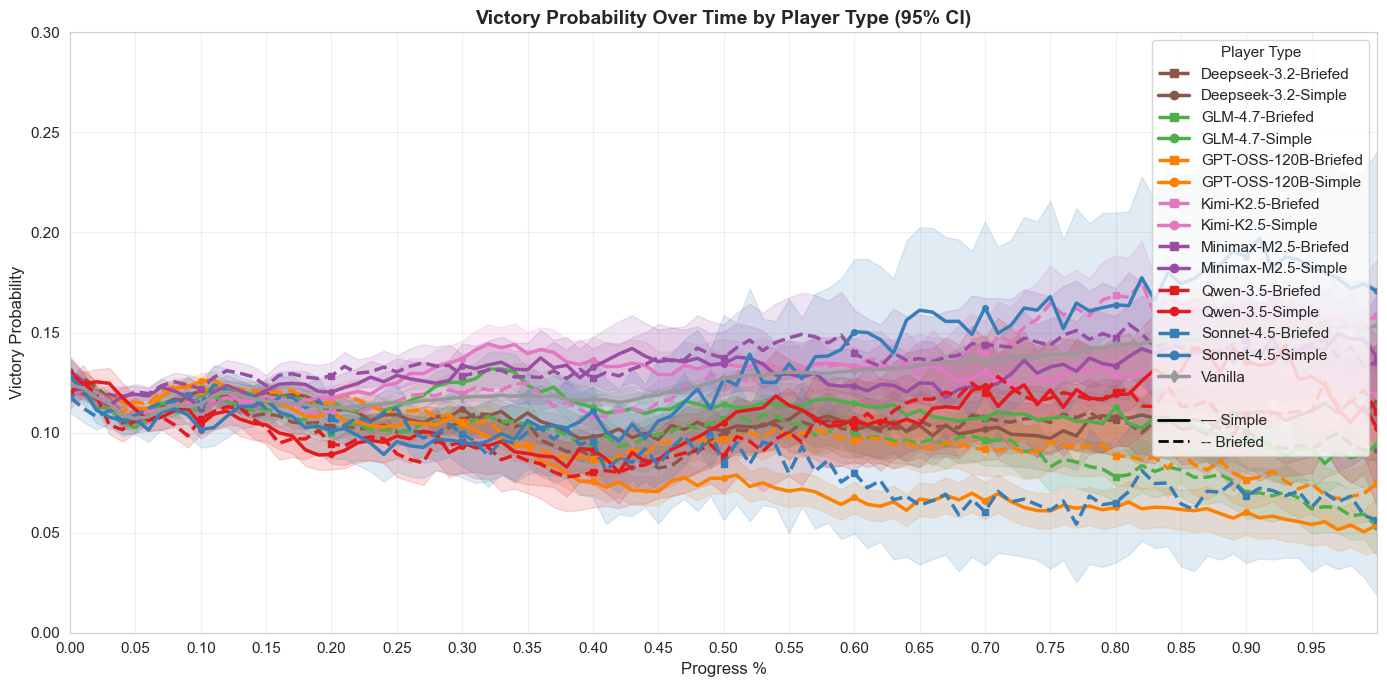

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,0.103,0.144,0.001,0.893,-0.010965,-0.022
Deepseek-3.2-Simple,49080,0.107,0.158,0.001,0.960,-0.008752,-0.016
GLM-4.7-Briefed,75725,0.096,0.137,0.001,0.954,-0.044532,-0.094
GLM-4.7-Simple,75725,0.111,0.156,0.001,0.968,-0.024711,-0.046
GPT-OSS-120B-Briefed,64583,0.098,0.139,0.001,0.958,-0.045330,-0.094
GPT-OSS-120B-Simple,64583,0.082,0.105,0.001,0.885,-0.074597,-0.205
Kimi-K2.5-Briefed,60817,0.132,0.176,0.001,0.935,0.060359,0.099
Kimi-K2.5-Simple,60817,0.128,0.164,0.001,0.937,0.009925,0.018
Minimax-M2.5-Briefed,38430,0.136,0.183,0.001,0.939,0.024493,0.039
Minimax-M2.5-Simple,38430,0.130,0.183,0.001,0.954,0.019660,0.031


In [78]:
fig, ax = plot_metric_over_time(
    turn_df,
    metric_calculation=lambda df: df['predicted_win_probability'],
    title="Victory Probability Over Time by Player Type",
    ylabel="Victory Probability",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, 0.3)
)

In [79]:
# =====================================================
# PLAYER STRENGTH: QUADRATIC WEIGHTED AVERAGE
# =====================================================
# Calculate player strength using quadratic weights that emphasize late-game performance
# Uses log-odds transformation for averaging to handle extreme probabilities properly

# Define logit and inverse logit transformations
def logit(p):
    """Transform probability to log-odds space"""
    # Clip to avoid log(0) or log of negative numbers
    p_clipped = np.clip(p, 1e-5, 1 - 1e-5)
    return np.log(p_clipped / (1 - p_clipped))

def inv_logit(x):
    """Transform log-odds back to probability space"""
    return 1 / (1 + np.exp(-x))


# First, average log-odds within each turn_progress group
# This handles cases where multiple turns have the same rounded turn_progress value
turn_progress_avg = turn_df[turn_df['turn_progress'] > 0.2].groupby(['game_id', 'player_id', 'turn_progress']).agg({
    'predicted_win_probability': 'mean',
    'player_type': 'first',
    'experiment': 'first',
    'is_winner': 'last',
    'civilization': 'first'
}).reset_index()
# Calculate weights based on unique turn_progress values
# Weight = turn_progress, where turn_progress ranges from 0 to 1
turn_progress_avg['quadratic_weight'] = turn_progress_avg['turn_progress']

# Calculate weighted average of log-odds for each player
weighted_strength = []

for (game_id, player_id), group in turn_progress_avg.groupby(['game_id', 'player_id']):
    # Calculate weighted average across unique turn_progress values in
    weights = group['quadratic_weight']
    probability = group['predicted_win_probability']
    weighted_avg_probability = (weights * probability).sum() / weights.sum()
    
    # Get player type and other info
    player_type = group['player_type'].iloc[0]
    civilization = group['civilization'].iloc[0]
    experiment = group['experiment'].iloc[0]
    is_winner = group['is_winner'].iloc[-1]  # Winner status from final turn
    
    weighted_strength.append({
        'game_id': game_id,
        'player_id': player_id,
        'player_type': player_type,
        'civilization': civilization,
        'experiment': experiment,
        'weighted_strength': weighted_avg_probability,
        'is_winner': is_winner
    })

strength_df = pd.DataFrame(weighted_strength)

In [80]:
# =====================================================
# RELATIVE STRENGTH: STRENGTH RELATIVE TO GAME LEADER
# =====================================================
# Calculate each player's strength relative to the strongest player in their game

# For each game, find the maximum weighted strength
game_max_strength = strength_df.groupby('game_id')['weighted_strength'].max().reset_index()
game_max_strength.columns = ['game_id', 'max_weighted_strength']

# Merge back with the strength dataframe
strength_df = strength_df.merge(game_max_strength, on='game_id')

# Calculate relative strength as a ratio
strength_df['relative_strength'] = strength_df['weighted_strength'] / strength_df['max_weighted_strength']

player_level = strength_df.groupby(['player_type']).agg({
    'player_type': 'first',
    'relative_strength': 'mean',
})
print(player_level)

                               player_type  relative_strength
player_type                                                  
Deepseek-3.2-Briefed  Deepseek-3.2-Briefed           0.217259
Deepseek-3.2-Simple    Deepseek-3.2-Simple           0.204385
GLM-4.7-Briefed            GLM-4.7-Briefed           0.184513
GLM-4.7-Simple              GLM-4.7-Simple           0.201904
GPT-OSS-120B-Briefed  GPT-OSS-120B-Briefed           0.183837
GPT-OSS-120B-Simple    GPT-OSS-120B-Simple           0.149527
Kimi-K2.5-Briefed        Kimi-K2.5-Briefed           0.308195
Kimi-K2.5-Simple          Kimi-K2.5-Simple           0.275937
Minimax-M2.5-Briefed  Minimax-M2.5-Briefed           0.280760
Minimax-M2.5-Simple    Minimax-M2.5-Simple           0.256384
Qwen-3.5-Briefed          Qwen-3.5-Briefed           0.230781
Qwen-3.5-Simple            Qwen-3.5-Simple           0.240274
Sonnet-4.5-Briefed      Sonnet-4.5-Briefed           0.162244
Sonnet-4.5-Simple        Sonnet-4.5-Simple           0.298014
Vanilla 

In [81]:
winner_df = strength_df[strength_df['is_winner'] == 1]

# Display summary statistics
print(f"Winner's Strength Statistics:")
print(f"  Mean: {winner_df['relative_strength'].mean():.3f}")
print(f"  Median: {winner_df['relative_strength'].median():.3f}")
print(f"  Std Dev: {winner_df['relative_strength'].std():.3f}")
print(f"  Min: {winner_df['relative_strength'].min():.3f}")
print(f"  Max: {winner_df['relative_strength'].max():.3f}")

Winner's Strength Statistics:
  Mean: 0.877
  Median: 1.000
  Std Dev: 0.240
  Min: 0.042
  Max: 1.000


In [82]:
# =====================================================
# OUTLIERS: WINNERS WITH MINIMAL RELATIVE STRENGTH
# =====================================================
# Display winners who won despite having low relative strength (underdogs)

print("\n" + "=" * 60)
print("OUTLIERS: Winners with Minimal Relative Strength")
print("=" * 60)

winner_df = strength_df[strength_df['is_winner'] == 1]
# Get bottom 10 winners by relative strength
outliers = winner_df.nsmallest(10, 'relative_strength')[
    ['game_id', 'player_id', 'player_type', 'civilization', 'experiment', 
     'relative_strength', 'weighted_strength', 'max_weighted_strength']
].reset_index(drop=True)

# Display with formatted output
print(f"\nTop 10 'Underdog' Winners (lowest relative strength):\n")
for idx, row in outliers.iterrows():
    print(f"{idx+1}. Game {row['game_id']}, Player {row['player_id']}")
    print(f"   Player Type: {row['player_type']}")
    print(f"   Civilization: {row['civilization']}")
    print(f"   Experiment: {row['experiment']}")
    print(f"   Relative Strength: {row['relative_strength']:.3f}")
    print(f"   Weighted Strength: {row['weighted_strength']:.4f}")
    print(f"   Game Leader Strength: {row['max_weighted_strength']:.4f}")
    print()


OUTLIERS: Winners with Minimal Relative Strength

Top 10 'Underdog' Winners (lowest relative strength):

1. Game ff11198e-eac8-4f33-80bd-a7b2ca975dc0, Player 4
   Player Type: GPT-OSS-120B-Simple
   Civilization: Germany
   Experiment: 2026-staff-standard
   Relative Strength: 0.042
   Weighted Strength: 0.0260
   Game Leader Strength: 0.6197

2. Game 48fa2cac-5861-4770-9c8d-b4f0e2abcadb, Player 1
   Player Type: Vanilla
   Civilization: England
   Experiment: observe-vanilla-standard
   Relative Strength: 0.053
   Weighted Strength: 0.0157
   Game Leader Strength: 0.2959

3. Game c6817e9a-d305-43ee-9648-d15a7eca8009, Player 1
   Player Type: Vanilla
   Civilization: Spain
   Experiment: observe-vanilla-standard
   Relative Strength: 0.060
   Weighted Strength: 0.0314
   Game Leader Strength: 0.5253

4. Game f051d432-aab6-4a4e-8c73-4c713fc940ca, Player 7
   Player Type: Vanilla
   Civilization: Egypt
   Experiment: observe-vanilla-standard
   Relative Strength: 0.080
   Weighted Stren

In [83]:
# Adjust all winners to have relative_strength = 0.0 (The best)

# For each winner, set relative_strength to 1.0 and adjust weighted_strength
for idx, row in strength_df[strength_df['is_winner'] == 1].iterrows():
    if row['relative_strength'] < 1.0:
        # Update weighted_strength to maintain consistency (+0.001 to make sure it is ranked #1)
        strength_df.at[idx, 'weighted_strength'] = row['max_weighted_strength'] + 0.001
        strength_df.at[idx, 'relative_strength'] = 1.0

player_level = strength_df.groupby(['player_type']).agg({
    'player_type': 'first',
    'relative_strength': 'mean',
})
print(player_level)

                               player_type  relative_strength
player_type                                                  
Deepseek-3.2-Briefed  Deepseek-3.2-Briefed           0.219665
Deepseek-3.2-Simple    Deepseek-3.2-Simple           0.210732
GLM-4.7-Briefed            GLM-4.7-Briefed           0.186455
GLM-4.7-Simple              GLM-4.7-Simple           0.206421
GPT-OSS-120B-Briefed  GPT-OSS-120B-Briefed           0.194243
GPT-OSS-120B-Simple    GPT-OSS-120B-Simple           0.172932
Kimi-K2.5-Briefed        Kimi-K2.5-Briefed           0.332866
Kimi-K2.5-Simple          Kimi-K2.5-Simple           0.279819
Minimax-M2.5-Briefed  Minimax-M2.5-Briefed           0.302765
Minimax-M2.5-Simple    Minimax-M2.5-Simple           0.276218
Qwen-3.5-Briefed          Qwen-3.5-Briefed           0.297817
Qwen-3.5-Simple            Qwen-3.5-Simple           0.271699
Sonnet-4.5-Briefed      Sonnet-4.5-Briefed           0.180731
Sonnet-4.5-Simple        Sonnet-4.5-Simple           0.324132
Vanilla 

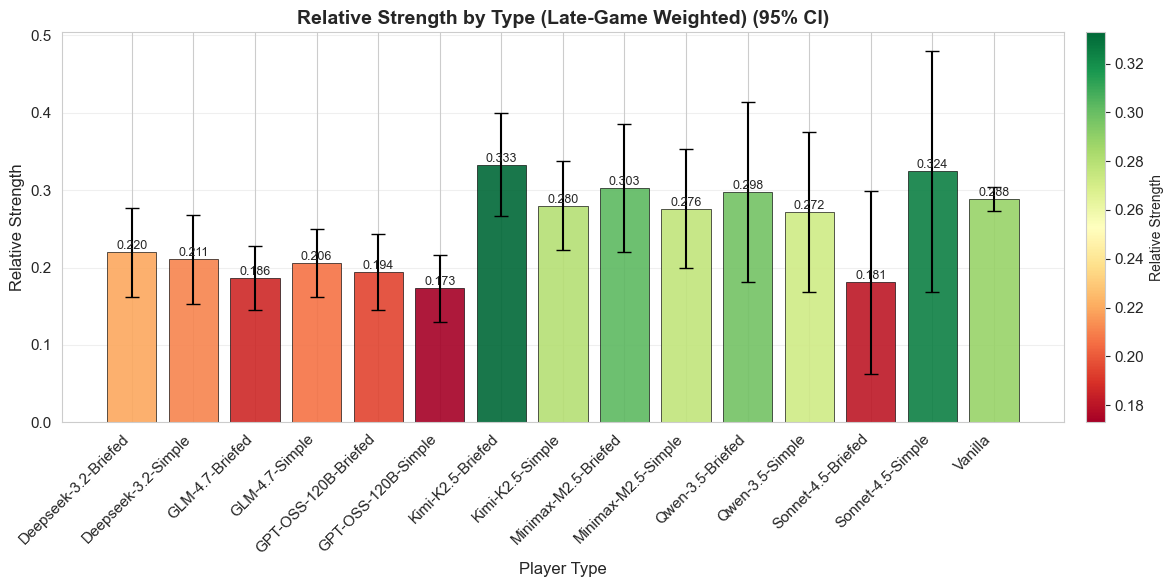

,Mean,Std,N
Deepseek-3.2-Briefed,0.219665,0.315361,115
Deepseek-3.2-Simple,0.210732,0.315186,115
GLM-4.7-Briefed,0.186455,0.281856,179
GLM-4.7-Simple,0.206421,0.300442,179
GPT-OSS-120B-Briefed,0.194243,0.310253,153
GPT-OSS-120B-Simple,0.172932,0.275267,153
Kimi-K2.5-Briefed,0.332866,0.407925,143
Kimi-K2.5-Simple,0.279819,0.352234,143
Minimax-M2.5-Briefed,0.302765,0.400572,91
Minimax-M2.5-Simple,0.276218,0.373873,91


In [84]:
# Plot bar chart of average relative strength by player type
plot_bar_chart(
    strength_df,
    category_col='player_type',
    value_col='relative_strength',
    use_percentage=False,
    xlabel='Player Type',
    ylabel='Relative Strength',
    title='Relative Strength by Type (Late-Game Weighted)',
    show_error_bars=True,
    confidence_level=0.95,
    value_format='{:.3f}',
    rotation=45,
    colormap='RdYlGn',
    figsize=(12, 6)
)

In [85]:
# =====================================================
# FIT LINEAR REGRESSION MODEL
# =====================================================
# This section fits the main linear regression model using statsmodels.
# The model includes fixed effects for players, civilizations, and conditions.

import statsmodels.api as sm
from statsmodels.formula.api import ols
from patsy.contrasts import Sum

print("=" * 60)
print("LINEAR REGRESSION: relative_strength")
print("=" * 60)

# Model specification with treatment coding for conditions and deviation coding for civilizations
# Vanilla Game (no LLM strategist) serves as the baseline for conditions
# Deviation coding (Sum) for civilizations centers effects around the mean
formula = 'relative_strength ~ C(civilization, Sum) + C(player_type, Treatment(reference="Vanilla"))'
model = ols(formula, data=strength_df).fit()

print("\nModel: Player ID, Civilization, and Condition Fixed Effects")
print("Baseline category for condition: Vanilla Game")
print("Civilization coding: Deviation (Sum) - effects relative to mean")
print(model.summary())

LINEAR REGRESSION: relative_strength

Model: Player ID, Civilization, and Condition Fixed Effects
Baseline category for condition: Vanilla Game
Civilization coding: Deviation (Sum) - effects relative to mean
                            OLS Regression Results                            
Dep. Variable:      relative_strength   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     9.791
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.66e-75
Time:                        15:42:50   Log-Likelihood:                -1279.0
No. Observations:                3792   AIC:                             2672.
Df Residuals:                    3735   BIC:                             3028.
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
  

In [86]:
# =====================================================
# PREPARE DATA FOR VISUALIZATION
# =====================================================
# Extract coefficients and prepare data for forest plots using utility functions

# Get model results
params = model.params
conf_int = model.conf_int()
pvalues = model.pvalues

# Extract and prepare condition effects (LLM strategist)
condition_vars = [col for col in params.index if 'player_type' in col and col != 'Intercept']
condition_df = prepare_coefficient_data(params, conf_int, pvalues, condition_vars, var_type='condition')

# Extract and prepare civilization effects
civ_vars = [col for col in params.index if 'civilization' in col]
civ_df = prepare_coefficient_data(params, conf_int, pvalues, civ_vars, var_type='civilization')


Effect of LLM Strategist on Relative Strength
(95% Confidence Intervals) SUMMARY

Baseline: (Vanilla baseline)

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Deepseek-3.2-Briefed           -0.067 [-0.131, -0.002] *
  Deepseek-3.2-Simple            -0.078 [-0.142, -0.013] *
  GLM-4.7-Briefed                -0.094 [-0.146, -0.042] ***
  GLM-4.7-Simple                 -0.079 [-0.131, -0.027] **
  GPT-OSS-120B-Briefed           -0.099 [-0.155, -0.043] ***
  GPT-OSS-120B-Simple            -0.106 [-0.162, -0.050] ***

Non-Significant Effects:
----------------------------------------
  Kimi-K2.5-Briefed              +0.050 [-0.008, +0.107]
  Kimi-K2.5-Simple               -0.033 [-0.091, +0.025]
  Minimax-M2.5-Briefed           +0.025 [-0.047, +0.097]
  Minimax-M2.5-Simple            -0.019 [-0.091, +0.053]
  Qwen-3.5-Briefed               +0.009 [-0.090, +0.109]
  Qwen-3.5-Simple                -0.027 [-0.126, +0.072]
  Sonnet-4.5-Briefed          

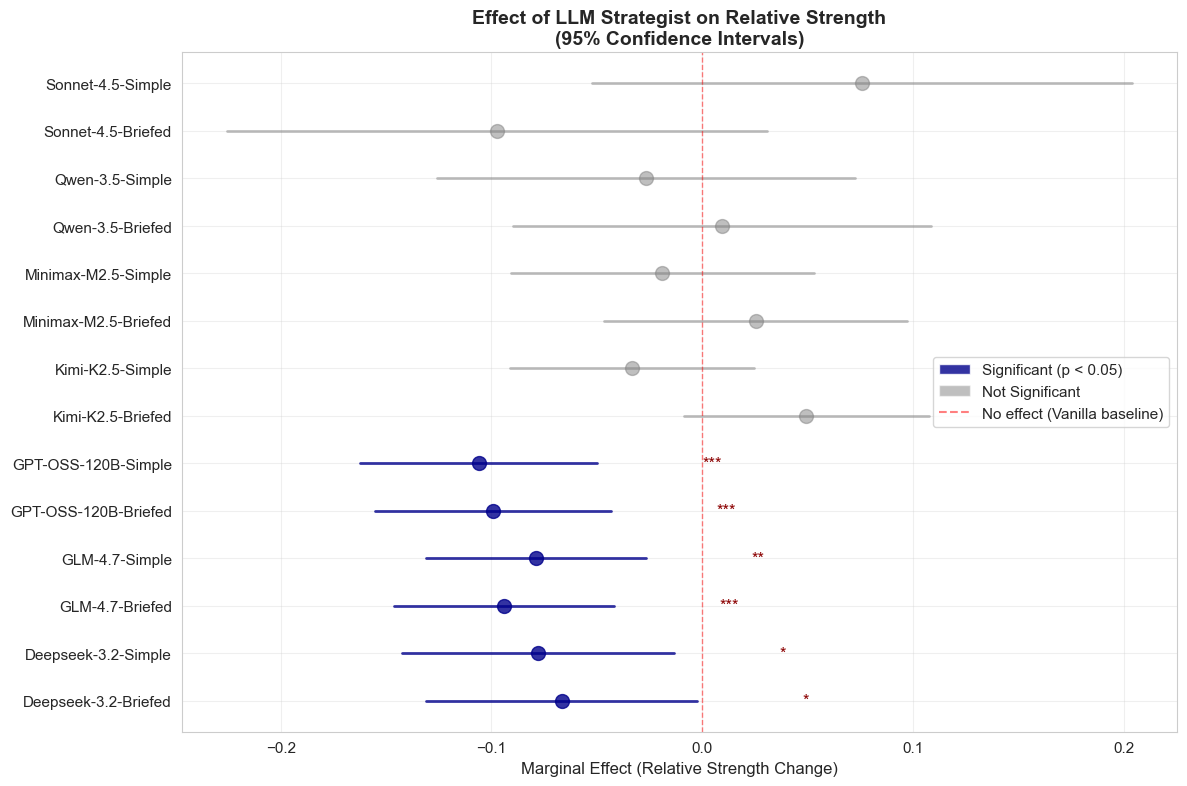

In [87]:
# =====================================================
# VISUALIZATION 1: LLM STRATEGIST EFFECTS
# =====================================================
# Create forest plot showing how LLM strategists affect score ratio
# compared to vanilla gameplay (no LLM strategist)

# Create forest plot for conditions with integrated summary
fig, ax = plot_forest_plot(
    condition_df, 
    title='Effect of LLM Strategist on Relative Strength\n(95% Confidence Intervals)',
    xlabel='Marginal Effect (Relative Strength Change)',
    color='darkblue',
    figsize=(12, 8),
    reference_line_label='No effect (Vanilla baseline)',
    use_prob_scale=False,  # Use raw scale for score ratio
    sort_alphabetically=True
)

plt.show()


Civilization Effects on Relative Strength
(Relative to Mean, 95% Confidence Intervals) SUMMARY

Baseline: Average of all civilization effect

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Mongolia                       -0.210 [-0.280, -0.140] ***
  Denmark                        -0.166 [-0.236, -0.097] ***
  Assyria                        -0.163 [-0.232, -0.094] ***
  Persia                         -0.154 [-0.218, -0.090] ***
  Japan                          -0.150 [-0.214, -0.086] ***
  America                        -0.145 [-0.210, -0.079] ***
  Rome                           -0.140 [-0.206, -0.073] ***
  England                        -0.122 [-0.198, -0.045] **
  Korea                          -0.100 [-0.175, -0.026] **
  Sweden                         -0.100 [-0.175, -0.024] **
  France                         -0.094 [-0.167, -0.020] *
  The Huns                       -0.089 [-0.158, -0.020] *
  Songhai                        -0.088 [-0.1

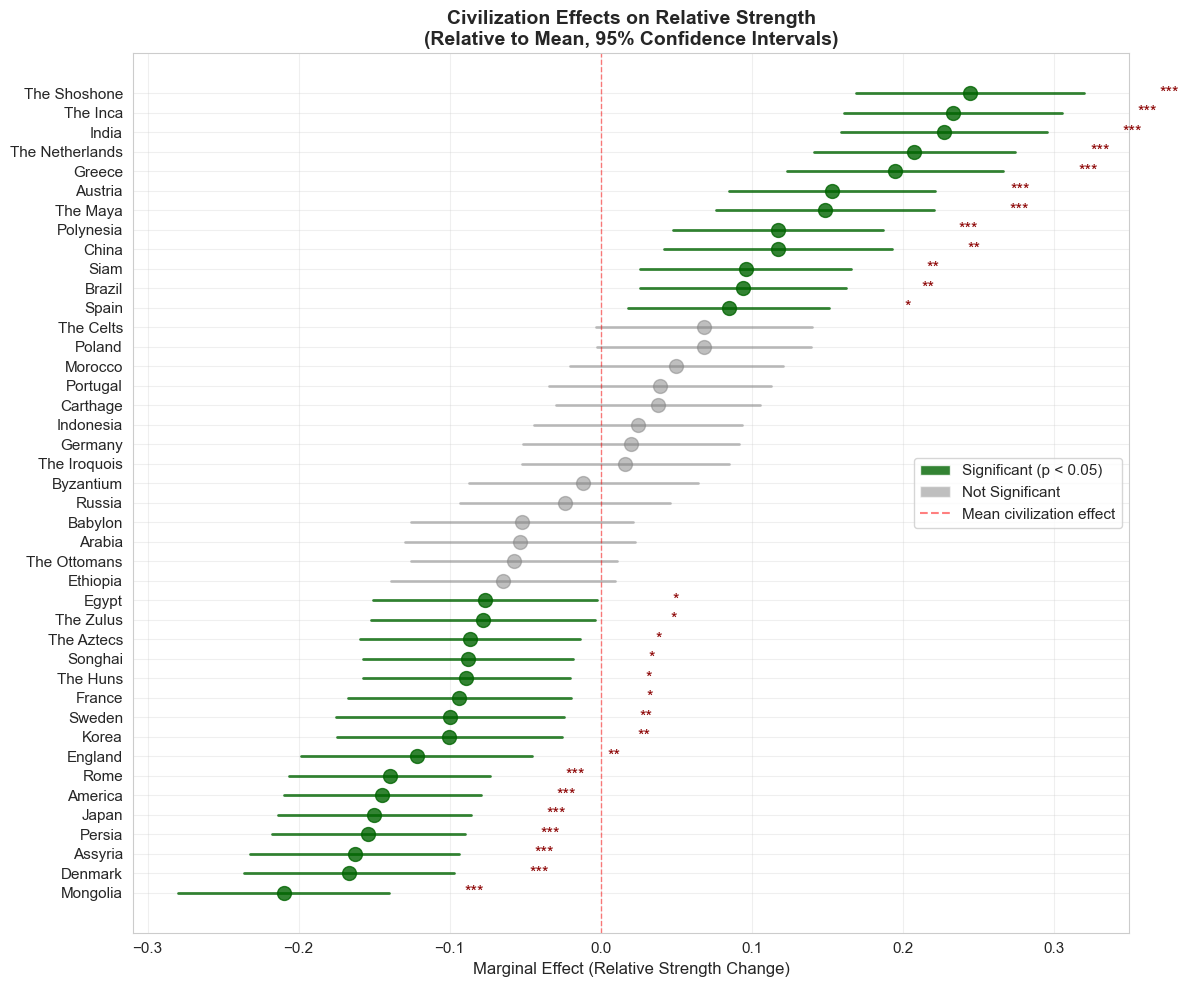

In [88]:
# =====================================================
# VISUALIZATION 2: CIVILIZATION EFFECTS (RELATIVE TO MEAN)
# =====================================================
# Create forest plot showing civilization strength relative to the mean
# This approach uses the average civilization performance as the baseline

# Create forest plot for civilizations with integrated summary
fig, ax = plot_forest_plot(
    civ_df,
    title='Civilization Effects on Relative Strength\n(Relative to Mean, 95% Confidence Intervals)',
    xlabel='Marginal Effect (Relative Strength Change)',
    color='darkgreen',
    figsize=(12, 10),
    reference_line_label='Mean civilization effect',
    use_prob_scale=False,  # Use raw scale for score ratio
)

plt.show()

In [89]:
# =====================================================
# CIVILIZATION FIXED EFFECTS: ADJUST FOR CIV ADVANTAGES
# =====================================================
# Extract civilization effects from the OLS model to adjust for civ advantages

# Create civilization effects lookup dictionary
civ_effects = {}
for var in civ_vars:
    # Extract civilization name from variable string
    # Format: "C(civilization, Sum)[S.CivName]"
    civ_name = var.split('[S.')[-1].rstrip(']')
    civ_effects[civ_name] = params[var]

# For the reference category (implied by Sum coding), calculate the negative sum
# Sum coding means all effects sum to zero
civ_effects['Venice'] = -sum(civ_effects.values())  # Venice is the missing civ

# Add adjusted_strength column to strength_df
# This removes the civilization advantage/disadvantage
strength_df['adjusted_strength'] = strength_df.apply(
    lambda row: row['relative_strength'] - civ_effects.get(row['civilization'], 0),
    axis=1
)
strength_df = strength_df[~strength_df['experiment'].isin(["observe-vanilla-standard"])]

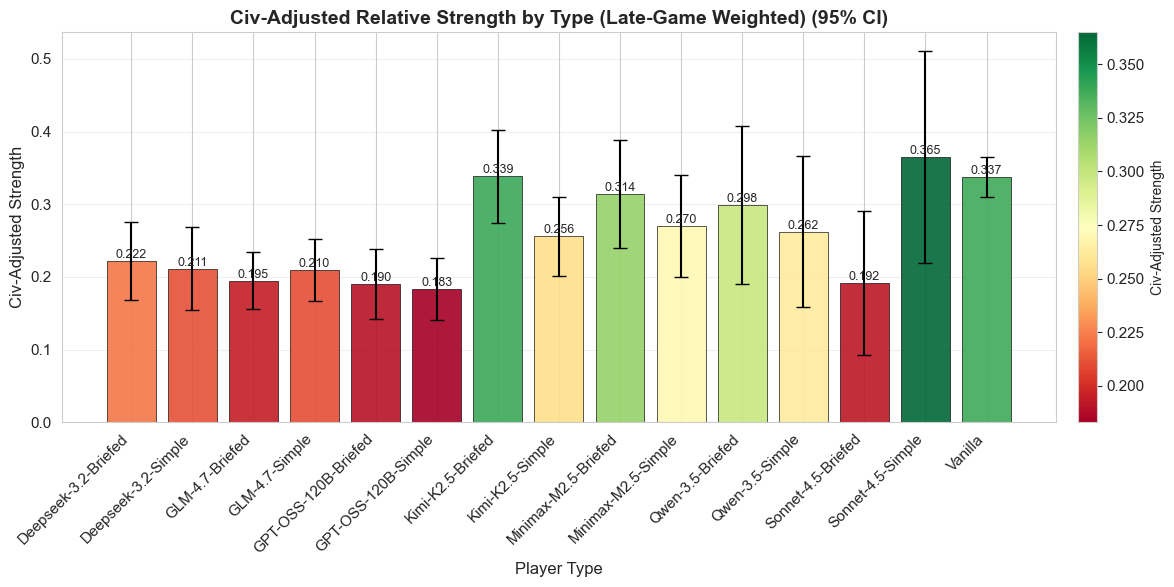

,Mean,Std,N
Deepseek-3.2-Briefed,0.222389,0.293250,115
Deepseek-3.2-Simple,0.211198,0.312694,115
GLM-4.7-Briefed,0.194834,0.267835,179
GLM-4.7-Simple,0.210107,0.290869,179
GPT-OSS-120B-Briefed,0.189848,0.302456,153
GPT-OSS-120B-Simple,0.182977,0.268843,153
Kimi-K2.5-Briefed,0.338544,0.391279,143
Kimi-K2.5-Simple,0.255666,0.329181,143
Minimax-M2.5-Briefed,0.314447,0.362068,91
Minimax-M2.5-Simple,0.270034,0.341206,91


In [90]:
# Plot bar chart of average weighted strength by player type
plot_bar_chart(
    strength_df,
    category_col='player_type',
    value_col='adjusted_strength',
    use_percentage=False,
    xlabel='Player Type',
    ylabel='Civ-Adjusted Strength',
    title='Civ-Adjusted Relative Strength by Type (Late-Game Weighted)',
    show_error_bars=True,
    confidence_level=0.95,
    value_format='{:.3f}',
    rotation=45,
    colormap='RdYlGn',
    figsize=(12, 6)
)

In [91]:
# =====================================================
# RATING CALCULATION: USING Score-weighted BT
# =====================================================
# Calculate player ratings using BT (Bradley-Terry)
# with continuous pairwise strength comparisons (not ordinal rankings)

from ratings import calculate_ratings, calculate_ratings_bt, compare_with_ols

# Calculate ratings with BT
rating_summary_df = calculate_ratings_bt(
    strength_df,
    verbose=True
)

CALCULATING RATINGS USING BRADLEY-TERRY MLE (R)

Total games: 280
Player types: ['Deepseek-3.2-Briefed', 'Deepseek-3.2-Simple', 'GLM-4.7-Briefed', 'GLM-4.7-Simple', 'GPT-OSS-120B-Briefed', 'GPT-OSS-120B-Simple', 'Kimi-K2.5-Briefed', 'Kimi-K2.5-Simple', 'Minimax-M2.5-Briefed', 'Minimax-M2.5-Simple', 'Qwen-3.5-Briefed', 'Qwen-3.5-Simple', 'Sonnet-4.5-Briefed', 'Sonnet-4.5-Simple', 'Vanilla']
Margin: auto-detect (median pairwise score diff)

Fitting model...
Bradley-Terry model fitted successfully.
Slots: 20 | Types: 15 | Games: 280 | Pairs: 6902 
Margin: 0.2435188 | Mean weight: 1.805 
Results written to: C:\Users\JOHNCH~1\AppData\Local\Temp\tmpwz3qtqru_output.csv

RATING SUMMARY (BRADLEY-TERRY MLE)
Rank   Player Type               Worth      Log-Worth    SE         Elo      p-value   
---------------------------------------------------------------------------------
1      Sonnet-4.5-Simple           1.0793     0.0763     0.1161     1513     0.5109
2      Vanilla                     1.00

VALIDATION: PLACKETT-LUCE MLE vs OLS COEFFICIENTS

Comparison of ranking methods:

Player Type               Rank     Log-Worth    OLS Coef    
---------------------------------------------------------
Sonnet-4.5-Simple         1            0.0763       0.0759
Vanilla                   2            0.0000       0.0000
Kimi-K2.5-Briefed         3           -0.1229       0.0495
Minimax-M2.5-Briefed      4           -0.1516       0.0254
Qwen-3.5-Briefed          5           -0.1897       0.0094
Minimax-M2.5-Simple       6           -0.2641      -0.0190
Qwen-3.5-Simple           7           -0.3475      -0.0266
Kimi-K2.5-Simple          8           -0.3869      -0.0334
Deepseek-3.2-Briefed      9           -0.4938      -0.0666
GLM-4.7-Simple            10          -0.5646      -0.0789
Sonnet-4.5-Briefed        11          -0.5772      -0.0974
GLM-4.7-Briefed           12          -0.5966      -0.0942
Deepseek-3.2-Simple       13          -0.6487      -0.0778
GPT-OSS-120B-Briefed      14   

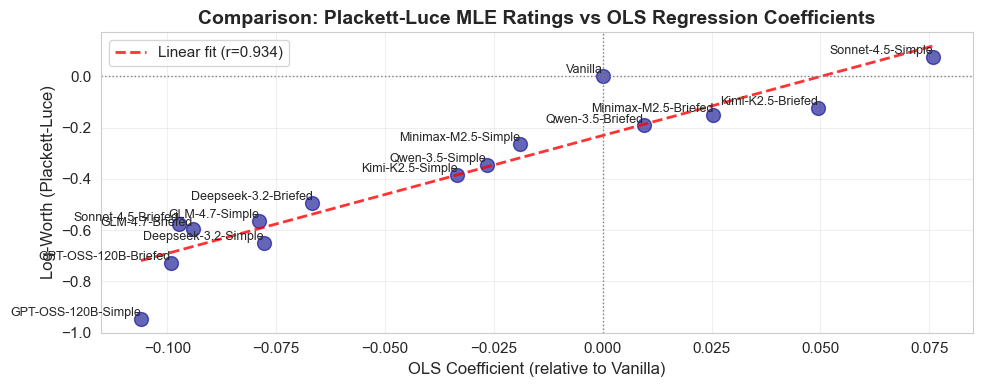

In [92]:
# =====================================================
# VALIDATION: RATING vs OLS COMPARISON
# =====================================================
# Compare Plackett-Luce ratings to OLS regression coefficients

comparison_df = compare_with_ols(rating_summary_df, model, baseline_type='Vanilla', baseline_rating=0.0, verbose=True)

# Scatter plot visualization
valid_comparison = comparison_df.dropna()
if len(valid_comparison) > 1:
    correlation = valid_comparison['rating_deviation'].corr(valid_comparison['ols_coefficient'])
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(valid_comparison['ols_coefficient'], valid_comparison['rating_deviation'], 
               s=100, alpha=0.6, color='darkblue')
    
    # Add labels for each point
    for _, row in valid_comparison.iterrows():
        ax.annotate(row['player_type'], 
                   (row['ols_coefficient'], row['rating_deviation']),
                   fontsize=9, ha='right', va='bottom')
    
    # Add trend line
    z = np.polyfit(valid_comparison['ols_coefficient'], valid_comparison['rating_deviation'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid_comparison['ols_coefficient'].min(), 
                        valid_comparison['ols_coefficient'].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label=f'Linear fit (r={correlation:.3f})')
    
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.axvline(0, color='gray', linestyle=':', linewidth=1)
    
    ax.set_xlabel('OLS Coefficient (relative to Vanilla)', fontsize=12)
    ax.set_ylabel('Log-Worth (Plackett-Luce)', fontsize=12)
    ax.set_title('Comparison: Plackett-Luce MLE Ratings vs OLS Regression Coefficients', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

HEAD-TO-HEAD MATCHUP MATRIX (EMPIRICAL)

Matrix dimensions: 15x15
Player types: 15
Total games analyzed: 280

Interpretation:
  - Rows: Player A
  - Columns: Player B
  - Value: Empirical P(A has higher adjusted strength than B)
  - P-values: One-way ANOVA testing if mean strengths differ

Sample sizes:
  Deepseek-3.2-Briefed vs Vanilla: 230 matchups
  Deepseek-3.2-Simple vs Vanilla: 230 matchups
  GLM-4.7-Briefed vs Vanilla: 498 matchups
  GLM-4.7-Simple vs Vanilla: 498 matchups
  GPT-OSS-120B-Briefed vs Vanilla: 466 matchups
  GPT-OSS-120B-Simple vs Vanilla: 466 matchups
  Kimi-K2.5-Briefed vs Vanilla: 286 matchups
  Kimi-K2.5-Simple vs Vanilla: 286 matchups
  Minimax-M2.5-Briefed vs Vanilla: 182 matchups
  Minimax-M2.5-Simple vs Vanilla: 182 matchups
  Qwen-3.5-Briefed vs Vanilla: 94 matchups
  Qwen-3.5-Simple vs Vanilla: 94 matchups
  Sonnet-4.5-Briefed vs Vanilla: 92 matchups
  Sonnet-4.5-Simple vs Vanilla: 92 matchups


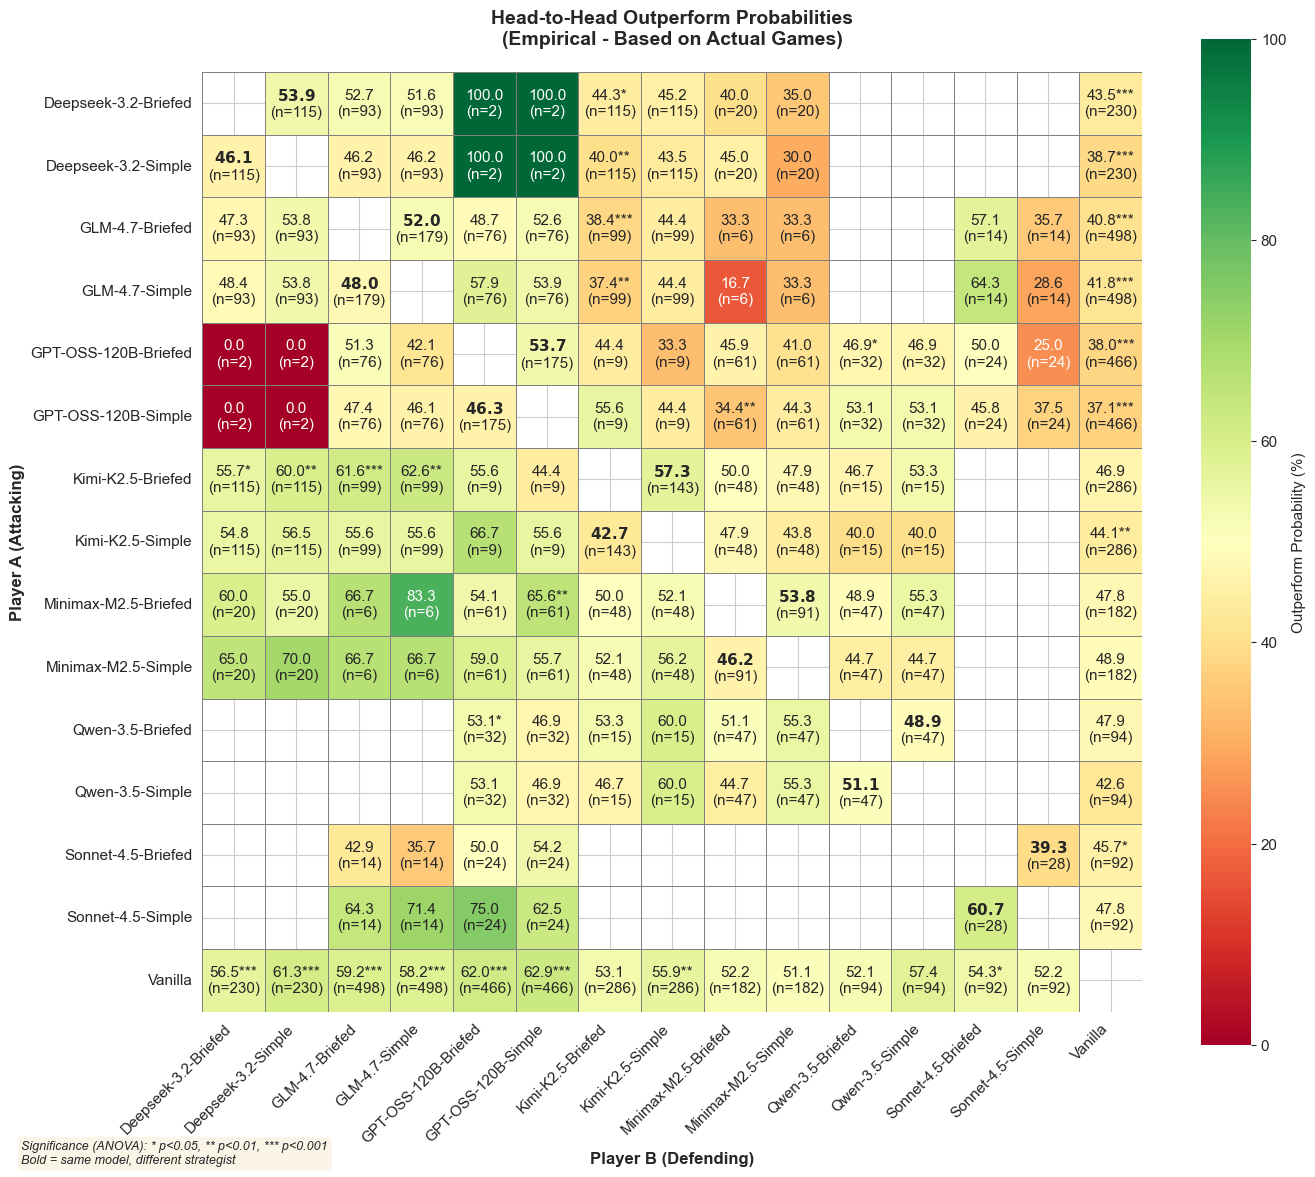


MATCHUP ANALYSIS

Deepseek-3.2-Briefed:
  vs Vanilla: 43.5% (n=230)
  Best matchup: vs GPT-OSS-120B-Briefed (100.0%, n=2)
  Worst matchup: vs Minimax-M2.5-Simple (35.0%, n=20)

Deepseek-3.2-Simple:
  vs Vanilla: 38.7% (n=230)
  Best matchup: vs GPT-OSS-120B-Briefed (100.0%, n=2)
  Worst matchup: vs Minimax-M2.5-Simple (30.0%, n=20)

GLM-4.7-Briefed:
  vs Vanilla: 40.8% (n=498)
  Best matchup: vs Sonnet-4.5-Briefed (57.1%, n=14)
  Worst matchup: vs Minimax-M2.5-Briefed (33.3%, n=6)

GLM-4.7-Simple:
  vs Vanilla: 41.8% (n=498)
  Best matchup: vs Sonnet-4.5-Briefed (64.3%, n=14)
  Worst matchup: vs Minimax-M2.5-Briefed (16.7%, n=6)

GPT-OSS-120B-Briefed:
  vs Vanilla: 38.0% (n=466)
  Best matchup: vs GPT-OSS-120B-Simple (53.7%, n=175)
  Worst matchup: vs Deepseek-3.2-Briefed (0.0%, n=2)

GPT-OSS-120B-Simple:
  vs Vanilla: 37.1% (n=466)
  Best matchup: vs Kimi-K2.5-Briefed (55.6%, n=9)
  Worst matchup: vs Deepseek-3.2-Briefed (0.0%, n=2)

Kimi-K2.5-Briefed:
  vs Vanilla: 46.9% (n=286)
  B

In [93]:
# =====================================================
# HEAD-TO-HEAD MATCHUP MATRIX
# =====================================================
# Calculate empirical pairwise outperform probabilities between all player types
# based on actual game data

from ratings import create_matchup_matrix
from plot_utilities import plot_matchup_heatmap

# Create matchup matrix using actual game data from strength_df
matchup_matrix_df, count_matrix_df, pvalue_matrix_df = create_matchup_matrix(
    strength_df,
    verbose=True
)

# Visualize as heatmap with percentages and match counts
fig, ax = plot_matchup_heatmap(
    matchup_matrix_df,
    count_df=count_matrix_df,
    pvalue_df=pvalue_matrix_df,
    title="Head-to-Head Outperform Probabilities\n(Empirical - Based on Actual Games)",
    figsize=(14, 12),
    as_percentage=True
)

plt.show()

# Matchup analysis with Vanilla baseline
print("\n" + "=" * 60)
print("MATCHUP ANALYSIS")
print("=" * 60)

for player in matchup_matrix_df.index:
    if player == 'Vanilla':
        continue  # Skip baseline
    
    # Find best matchup (highest outperform probability against non-self)
    matchups = matchup_matrix_df.loc[player]
    matchups_filtered = matchups[matchups.index != player].dropna()
    
    if len(matchups_filtered) == 0:
        continue
    
    best_opponent = matchups_filtered.idxmax()
    best_prob = matchups_filtered.max()
    best_count = count_matrix_df.loc[player, best_opponent]
    
    worst_opponent = matchups_filtered.idxmin()
    worst_prob = matchups_filtered.min()
    worst_count = count_matrix_df.loc[player, worst_opponent]
    
    # Get matchup vs Vanilla
    vanilla_prob = matchup_matrix_df.loc[player, 'Vanilla']
    vanilla_count = count_matrix_df.loc[player, 'Vanilla']
    
    print(f"\n{player}:")
    if pd.notna(vanilla_prob):
        print(f"  vs Vanilla: {vanilla_prob*100:.1f}% (n={int(vanilla_count)})")
    else:
        print(f"  vs Vanilla: No data")
    print(f"  Best matchup: vs {best_opponent} ({best_prob*100:.1f}%, n={int(best_count)})")
    print(f"  Worst matchup: vs {worst_opponent} ({worst_prob*100:.1f}%, n={int(worst_count)})")

HEAD-TO-HEAD MATCHUP MATRIX (MEAN STRENGTH DIFFERENCE)

Matrix dimensions: 15x15
Player types: 15
Total games analyzed: 280

Interpretation:
  - Rows: Player A
  - Columns: Player B
  - Value: Mean(A_adjusted_strength - B_adjusted_strength)
  - Positive = A is stronger on average
  - P-values: One-sample t-test (H0: mean diff = 0)


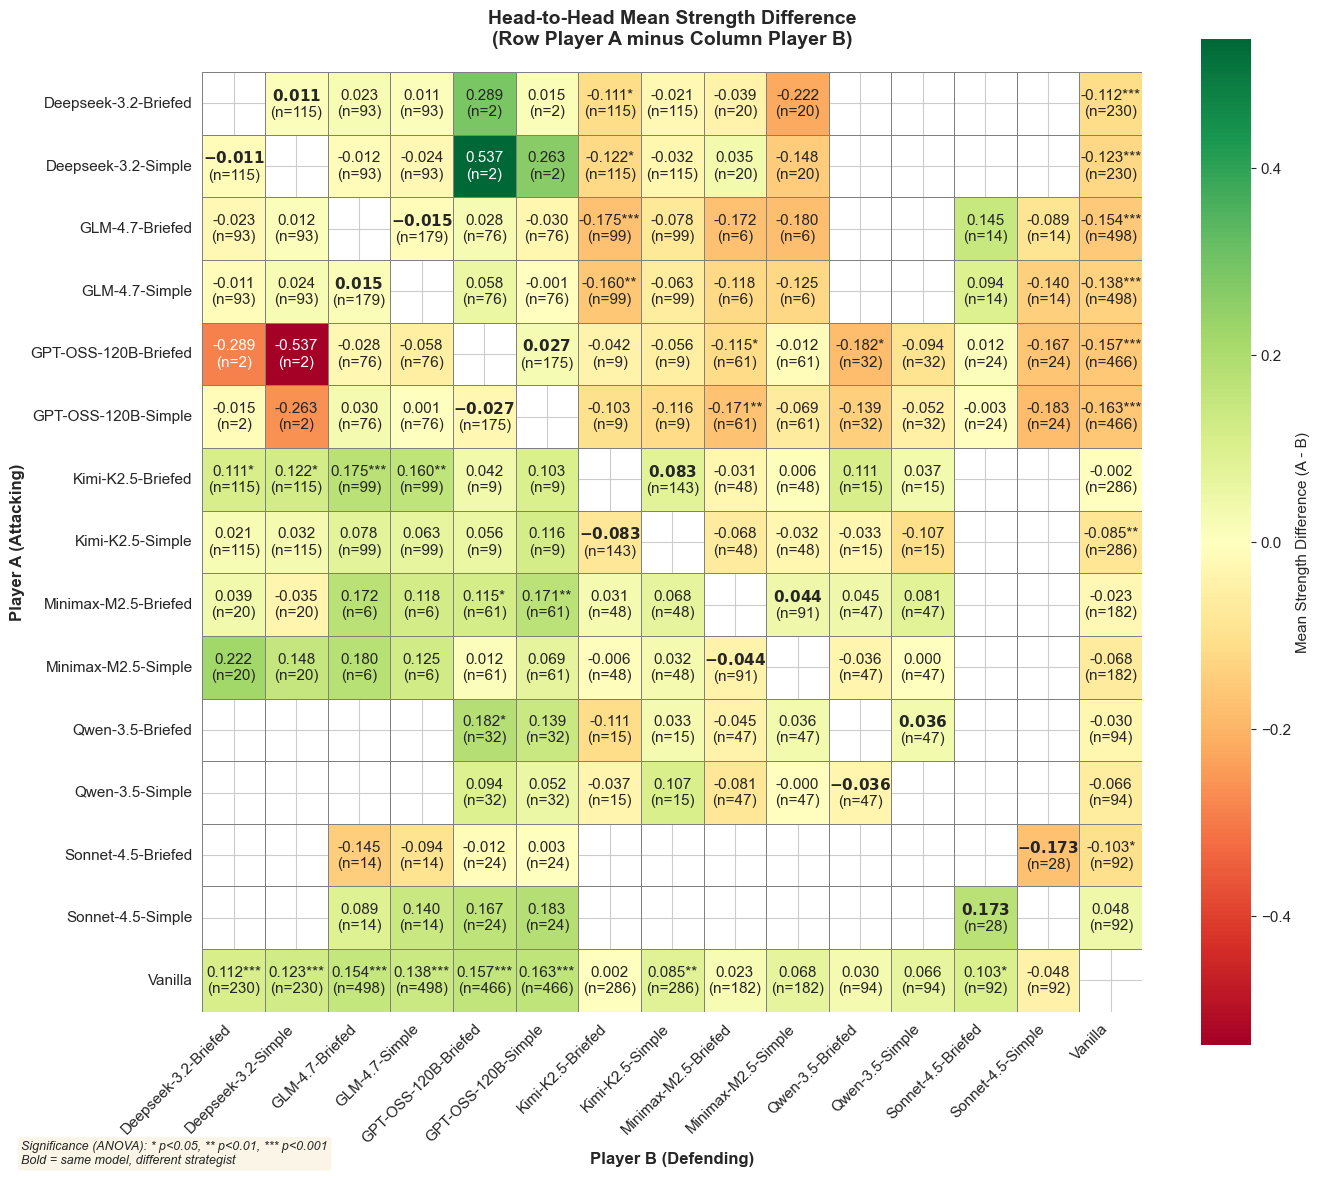


WIN-RATE vs MEAN-DIFFERENCE DISAGREEMENTS
Cases where win rate and mean difference point in opposite directions:

  Deepseek-3.2-Simple vs Minimax-M2.5-Briefed:
    Win rate: 45.0% | Mean diff: +0.0349 | n=20
  GLM-4.7-Briefed vs GLM-4.7-Simple:
    Win rate: 52.0% | Mean diff: -0.0153 | n=179
  GLM-4.7-Briefed vs GPT-OSS-120B-Briefed:
    Win rate: 48.7% | Mean diff: +0.0283 | n=76
  GLM-4.7-Briefed vs GPT-OSS-120B-Simple:
    Win rate: 52.6% | Mean diff: -0.0302 | n=76
  GLM-4.7-Simple vs GLM-4.7-Briefed:
    Win rate: 48.0% | Mean diff: +0.0153 | n=179
  GLM-4.7-Simple vs GPT-OSS-120B-Simple:
    Win rate: 53.9% | Mean diff: -0.0008 | n=76
  GPT-OSS-120B-Briefed vs GLM-4.7-Briefed:
    Win rate: 51.3% | Mean diff: -0.0283 | n=76
  GPT-OSS-120B-Simple vs GLM-4.7-Briefed:
    Win rate: 47.4% | Mean diff: +0.0302 | n=76
  GPT-OSS-120B-Simple vs GLM-4.7-Simple:
    Win rate: 46.1% | Mean diff: +0.0008 | n=76
  GPT-OSS-120B-Simple vs Kimi-K2.5-Briefed:
    Win rate: 55.6% | Mean diff: -

In [94]:
# =====================================================
# HEAD-TO-HEAD MATCHUP MATRIX (MEAN STRENGTH DIFFERENCE)
# =====================================================
# Complement the win-rate matrix with mean strength differences.
# A player can win <50% of comparisons but still be stronger on average
# (e.g., winning by small margins, losing by large ones).

from ratings import create_mean_matchup_matrix

mean_diff_df, mean_count_df, mean_pvalue_df = create_mean_matchup_matrix(
    strength_df,
    verbose=True
)

# Symmetric colormap range centered at 0
abs_max = np.nanmax(np.abs(mean_diff_df.values))

fig, ax = plot_matchup_heatmap(
    mean_diff_df,
    count_df=mean_count_df,
    pvalue_df=mean_pvalue_df,
    title="Head-to-Head Mean Strength Difference\n(Row Player A minus Column Player B)",
    figsize=(14, 12),
    as_percentage=False,
    vmin=-abs_max,
    vmax=abs_max,
    center=0,
    cbar_label='Mean Strength Difference (A - B)',
    annot_format='.3f'
)

plt.show()

# Compare win-rate vs mean-difference: flag disagreements
print("\n" + "=" * 60)
print("WIN-RATE vs MEAN-DIFFERENCE DISAGREEMENTS")
print("=" * 60)
print("Cases where win rate and mean difference point in opposite directions:\n")

found = False
for a in matchup_matrix_df.index:
    for b in matchup_matrix_df.columns:
        if a == b:
            continue
        wr = matchup_matrix_df.loc[a, b]
        md = mean_diff_df.loc[a, b]
        if pd.isna(wr) or pd.isna(md):
            continue
        # Win rate says A wins more often, but mean says A is weaker (or vice versa)
        if (wr > 0.5 and md < 0) or (wr < 0.5 and md > 0):
            n = int(mean_count_df.loc[a, b])
            found = True
            print(f"  {a} vs {b}:")
            print(f"    Win rate: {wr*100:.1f}% | Mean diff: {md:+.4f} | n={n}")

if not found:
    print("  None found — win rate and mean difference agree for all pairs.")


CIV-ADJUSTED WIN PROBABILITY: VALIDATION

Original mean: 0.1209
Adjusted mean: 0.1221

Original std: 0.1692
Adjusted std: 0.1790

Adjustment range: [-0.2100, 0.2446]
Mean adjustment magnitude: 0.1059


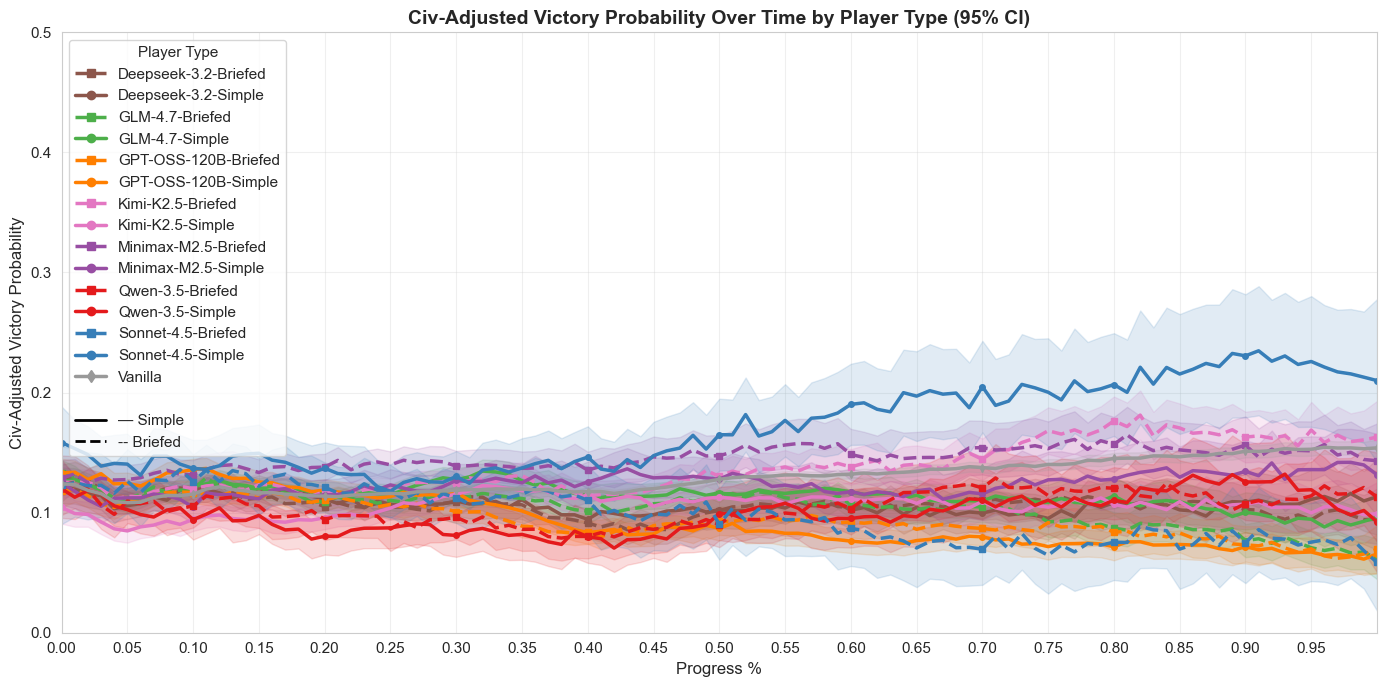

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,0.106,0.162,-0.243,1.085,-0.010991,-0.020
Deepseek-3.2-Simple,49080,0.106,0.182,-0.232,1.066,-0.008687,-0.014
GLM-4.7-Briefed,75725,0.104,0.157,-0.242,1.032,-0.045097,-0.083
GLM-4.7-Simple,75725,0.114,0.175,-0.243,0.995,-0.025037,-0.041
GPT-OSS-120B-Briefed,64583,0.093,0.162,-0.243,0.927,-0.044619,-0.080
GPT-OSS-120B-Simple,64583,0.093,0.136,-0.226,0.891,-0.073345,-0.156
Kimi-K2.5-Briefed,60817,0.138,0.191,-0.243,1.048,0.060326,0.091
Kimi-K2.5-Simple,60817,0.106,0.177,-0.243,0.987,0.009891,0.016
Minimax-M2.5-Briefed,38430,0.145,0.185,-0.225,1.025,0.024643,0.039
Minimax-M2.5-Simple,38430,0.124,0.192,-0.243,0.977,0.019857,0.030


In [95]:
# =====================================================
# CIV-ADJUSTED VICTORY PROBABILITY OVER TIME
# =====================================================
# Apply civilization adjustments (from Cell 12) to predicted_win_probability
# and visualize how player types perform when civilization bias is removed

# Apply the same civ_effects from Cell 12 to predicted_win_probability
turn_df['civ_adjusted_win_prob'] = turn_df.apply(
    lambda row: row['predicted_win_probability'] - civ_effects.get(row['civilization'], 0),
    axis=1
)

# Validation checks
print("\n" + "=" * 60)
print("CIV-ADJUSTED WIN PROBABILITY: VALIDATION")
print("=" * 60)
print(f"\nOriginal mean: {turn_df['predicted_win_probability'].mean():.4f}")
print(f"Adjusted mean: {turn_df['civ_adjusted_win_prob'].mean():.4f}")
print(f"\nOriginal std: {turn_df['predicted_win_probability'].std():.4f}")
print(f"Adjusted std: {turn_df['civ_adjusted_win_prob'].std():.4f}")

adjustment_range = turn_df['predicted_win_probability'] - turn_df['civ_adjusted_win_prob']
print(f"\nAdjustment range: [{adjustment_range.min():.4f}, {adjustment_range.max():.4f}]")
print(f"Mean adjustment magnitude: {adjustment_range.abs().mean():.4f}")

# Plot civ-adjusted win probability over time
fig, ax = plot_metric_over_time(
    turn_df,
    metric_calculation=lambda df: df['civ_adjusted_win_prob'],
    title="Civ-Adjusted Victory Probability Over Time by Player Type",
    ylabel="Civ-Adjusted Victory Probability",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, 0.5)
)